I️-Analyse de forme (structure et qualité des données)

In [110]:
#importation des bibliotheques pour le pretraitement des donnees
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



#chargement des donnees
df = pd.read_csv('Telco-Customer-Churn.csv')



#1. Combien de lignes (clients) et de colonnes contient la dataset ?
print("Nombre de lignes et de colonnes dans la dataset :", df.shape)

Nombre de lignes et de colonnes dans la dataset : (7043, 21)


In [111]:
#affichage des 5 premieres lignes de la dataset
df.drop('customerID',axis=1,inplace=True)
print("Aperçu des 5 premières lignes de la dataset :\n", df.head())


Aperçu des 5 premières lignes de la dataset :
    gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Mon

In [112]:
#2-Chaque observation correspond-elle bien à un client unique ?

#Oui, chaque ligne correspond à un client unique, identifié par la colonne customerID.

In [113]:
#3. Quels sont les types de variables présentes (numériques, catégorielles, binaires) ?
print("\nTypes de variables dans la dataset :\n", df.dtypes)


Types de variables dans la dataset :
 gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [114]:
#4. Quelle est la variable cible du problème ?
#la variable cible est "Churn", qui indique si un client a quitté le service (Yes) ou non (No).

In [115]:
#5. La variable Churn est-elle bien définie et cohérente ?
print("\nValeurs uniques de la variable cible Churn :\n", df['Churn'].value_counts())



Valeurs uniques de la variable cible Churn :
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [116]:
#6. Existe-t-il des valeurs manquantes dans la dataset ?
print("\nValeurs manquantes dans chaque colonne :\n", df.isnull().sum())


Valeurs manquantes dans chaque colonne :
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [117]:
#9. Quelles stratégies peuvent être utilisées pour traiter ces valeurs ?
#Pour traiter les valeurs manquantes, on peut utiliser plusieurs stratégies :
#Suppression des lignes(<5% de la taille des donnes) ou colonnes(>50% des donnes)avec trop de valeurs manquantes.
#Imputation des valeurs manquantes avec la moyenne, la médiane ou le mode.
#Utilisation de modèles prédictifs pour estimer les valeurs manquantes.

In [118]:
df.duplicated().sum()

22

In [119]:
df.drop_duplicates(inplace=True)

<Axes: >

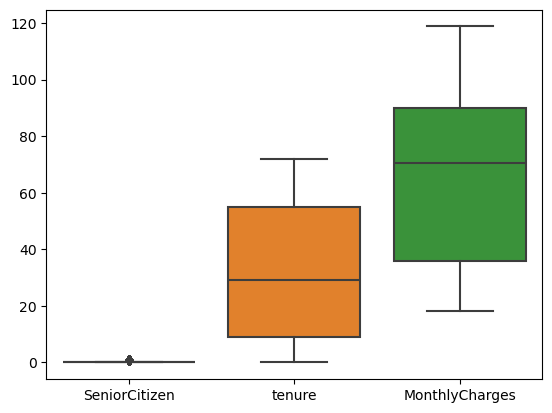

In [120]:
#10.Observe-t-on des valeurs aberrantes dans les variables numériques ?
col_num= df.drop('Churn',axis=1).select_dtypes(include='number')
sns.boxplot(col_num)
   



In [121]:
col_cat=df.drop('Churn',axis=1).select_dtypes(include='object')
#11.Certaines variables sont-elles redondantes ou peu informatives ?
col_num.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7021, dtype: bool

In [122]:
#12.Faut-il supprimer ou transformer certaines colonnes ?
#il faut transformer certaines variable cas nous avons des variables de type object

II️-Analyse de fond – distributions des variables

/home/foyem-yvan/anaconda3/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


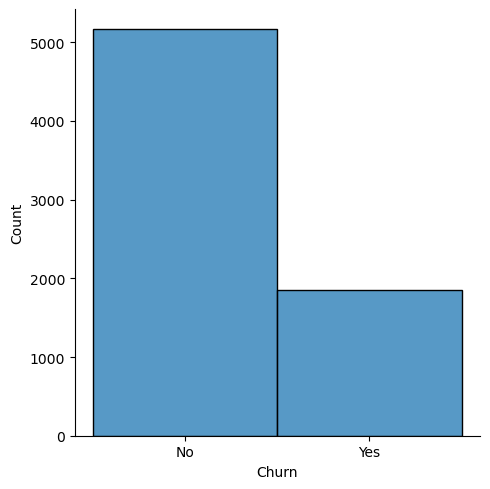

In [123]:
#13.Quelle est la distribution de la variable cible Churn ?
sns.displot(df['Churn'])

/home/foyem-yvan/anaconda3/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


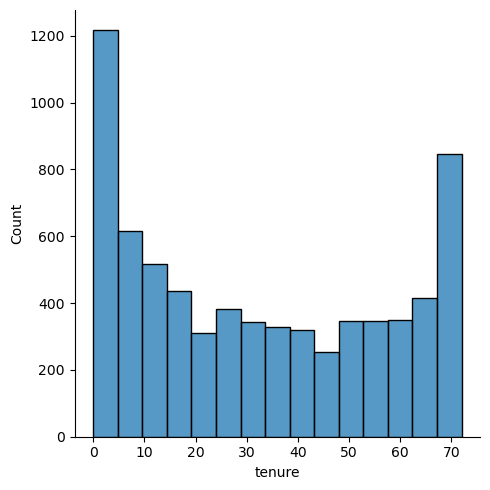

In [124]:
#15.Quelle est la distribution de l’ancienneté (tenure) des clients ?
sns.displot(df['tenure'])

/home/foyem-yvan/anaconda3/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


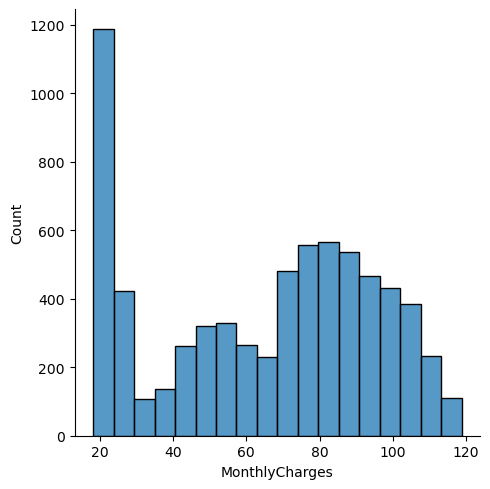

In [125]:
#17.Comment se répartissent les charges mensuelles (MonthlyCharges) ?
sns.displot(df['MonthlyCharges'])

/home/foyem-yvan/anaconda3/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


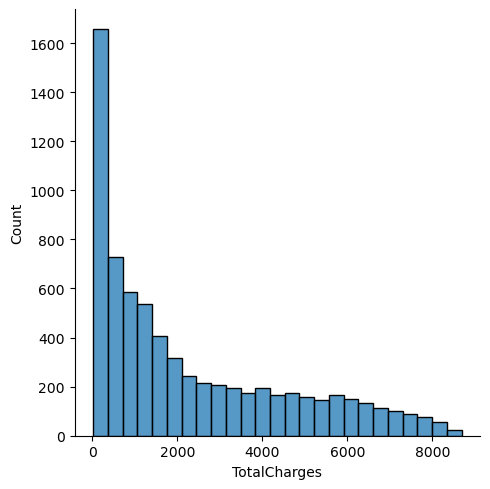

In [126]:
import numpy as np
#19.Quelle est la distribution du montant total payé (TotalCharges) ?
df['TotalCharges'] = df['TotalCharges'].str.strip()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
sns.displot(df['TotalCharges'])


<Axes: xlabel='tenure', ylabel='TotalCharges'>

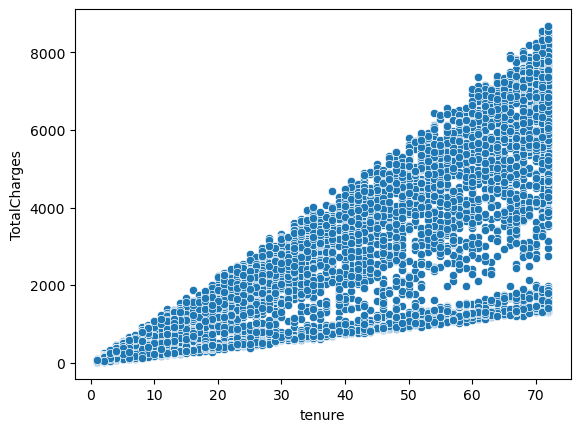

In [127]:
#20.Comment TotalCharges évolue-t-il en fonction de l’ancienneté ?
sns.scatterplot(data=df, x='tenure', y='TotalCharges')

III️-Analyse du churn selon les variables clés

In [128]:
#21.Le taux de churn varie-t-il selon l’ancienneté du client ?
#sns.scatterplot(data=df, x='tenure', y='Churn')
pd.crosstab(df['tenure'], df['Churn'])


Churn,No,Yes
tenure,,
0,11,0
1,223,368
2,115,123
3,106,94
4,93,83
...,...,...
68,91,9
69,87,8
70,108,11


In [129]:
#23.Les clients ayant des charges mensuelles élevées quittent-ils plus souvent le service ?
#sns.scatterplot(data=df, x='MonthlyCharges', y='Churn')
pd.crosstab(df['MonthlyCharges'], df['Churn']).sort_values(by='Yes', ascending=False)

Churn,No,Yes
MonthlyCharges,,
74.40,3,13
74.90,3,9
74.95,3,8
85.35,3,7
93.85,1,7
...,...,...
64.45,4,0
64.50,4,0
64.55,2,0


In [130]:
#24.Le type de contrat influence-t-il le taux de churn ?
# nous allons utliser le test de chi-2  
from scipy.stats import chi2_contingency
table = pd.crosstab(df['Contract'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(table)
if p < 0.05:
    print("le type de contrat influence le taux de churn (p-value =", p, ")")
else:    
    print("le type de contrat n'influence pas le taux de churn (p-value =", p, ")")


le type de contrat influence le taux de churn (p-value = 6.442284610021268e-257 )


In [131]:
#25.Les contrats mensuels sont-ils plus à risque que les contrats longue durée ?
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2210,1643
One year,1307,166
Two year,1647,48


In [132]:
#26.La méthode de paiement a-t-elle un impact sur le churn ?
table = pd.crosstab(df['PaymentMethod'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(table)
if p < 0.05:    
    print("la méthode de paiement influence le taux de churn (p-value =", p, ")")
else:
    print("la méthode de paiement n'influence pas le taux de churn (p-value =", p, ")")


la méthode de paiement influence le taux de churn (p-value = 3.0267752570875056e-139 )


<Axes: xlabel='PaperlessBilling', ylabel='Churn'>

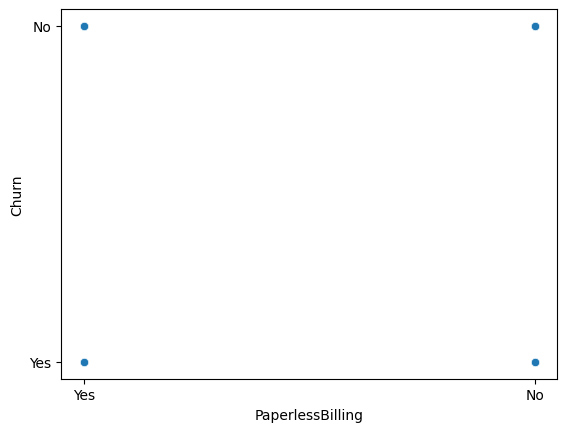

In [133]:
#27.La facturation électronique influence-t-elle le comportement des clients ?
sns.scatterplot(x='PaperlessBilling', y='Churn', data=df)

In [134]:
features=df.drop('Churn',axis=1).select_dtypes(include='object').columns
#target=df[['Churn']].columns
result = {}
for i in features:
    print("--"*40)
    table=pd.crosstab(df[i],df['Churn'])
    print(table,"\n")
    chi2,p,dof,expected = chi2_contingency(table)
    if p < 0.05:    
        print("la ",i,"influence le taux de churn (p-value=",p,"\n")
        result[i] = p
    else:
        print("la ",i,"n'influence  pas le taux de churn (p-value=",p,"\n")
    



--------------------------------------------------------------------------------
Churn     No  Yes
gender           
Female  2546  934
Male    2618  923 

la  gender n'influence  pas le taux de churn (p-value= 0.4794615390898278 

--------------------------------------------------------------------------------
Churn      No   Yes
Partner            
No       2431  1188
Yes      2733   669 

la  Partner influence le taux de churn (p-value= 1.0999615978939857e-35 

--------------------------------------------------------------------------------
Churn         No   Yes
Dependents            
No          3380  1531
Yes         1784   326 

la  Dependents influence le taux de churn (p-value= 1.5995676694072134e-42 

--------------------------------------------------------------------------------
Churn           No   Yes
PhoneService            
No             512   170
Yes           4652  1687 

la  PhoneService n'influence  pas le taux de churn (p-value= 0.3664940064978197 

---------------

V️-Analyse des corrélations et relations entre variables

In [135]:
df.dropna(inplace=True)

<Axes: >

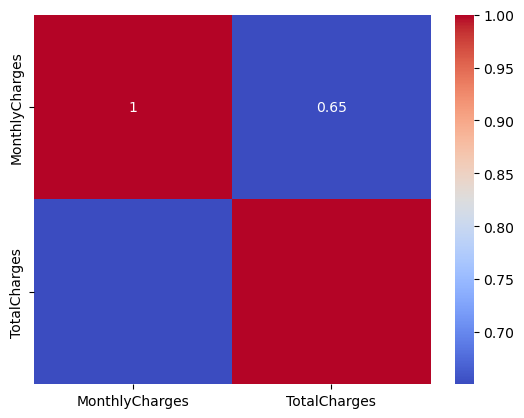

In [136]:
#36.Les variables financières sont-elles corrélées entre elles ?
col_financial = df[['MonthlyCharges', 'TotalCharges']]
cor=col_financial.corr()
sns.heatmap(cor, annot=True, cmap='coolwarm')


#les variables financières sont fortement corrélées entre elles, 
# avec une corrélation de 0.65 entre MonthlyCharges et TotalCharges.

In [137]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [138]:
#37.Peut-on identifier des variables fortement liées au churn ?
result

{'Partner': 1.0999615978939857e-35,
 'Dependents': 1.5995676694072134e-42,
 'MultipleLines': 0.0020685599531309134,
 'InternetService': 1.0857790034735195e-159,
 'OnlineSecurity': 1.329226523787891e-184,
 'OnlineBackup': 8.614898409283198e-131,
 'DeviceProtection': 1.9555513236078665e-121,
 'TechSupport': 7.146857715828324e-180,
 'StreamingTV': 5.469454144000632e-82,
 'StreamingMovies': 2.750289622934079e-82,
 'Contract': 6.442284610021268e-257,
 'PaperlessBilling': 2.1518977990247168e-57,
 'PaymentMethod': 3.0267752570875056e-139}


VI️-Synthèse exploratoire et lien avec le MLOps

In [139]:
#39.Quelles sont les variables les plus importantes pour expliquer le churn ?
result.keys()

dict_keys(['Partner', 'Dependents', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'])

In [140]:
#40.Peut-on identifier un profil type de client à risque ?
#oui

In [141]:
#41.Quelles transformations de données sont nécessaires avant la modélisation ?
#Les variables catégorielles doivent être encodées .
#Les variables numériques doivent être normalisées ou standardisées.
#Les valeurs manquantes doivent être traitées (supprimées ou imputées). 

from sklearn.preprocessing import LabelEncoder, StandardScaler,MinMaxScaler,OneHotEncoder
label = LabelEncoder()
oneHot = OneHotEncoder(sparse_output=False)
df['Churn'] = label.fit_transform(df['Churn'])
df = pd.get_dummies(df.drop('Churn',axis=1), drop_first=True).astype(int)
